# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [ ]:
#Seu código de importação aqui
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", sep=';', encoding='utf-8-sig')

#Convertendo colunas numéricas (garantindo que Total_Pago seja numérico)
df['Total_Pago'] = pd.to_numeric(df['Total_Pago'], errors='coerce')
df['Pagamento_Mensal'] = pd.to_numeric(df['Pagamento_Mensal'], errors='coerce')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

--- ITEM 2A: Describe ---
            Idoso  Tempo_como_Cliente  Pagamento_Mensal   Total_Pago
count  2500.00000         2500.000000       2175.000000  2500.000000
mean      0.16080           32.341600         65.607563  2291.882880
std       0.36742           24.626398         29.931520  2265.347752
min       0.00000            0.000000         18.400000    18.800000
25%       0.00000            8.000000         39.500000   402.337500
50%       0.00000           29.000000         71.450000  1405.325000
75%       0.00000           56.000000         90.250000  3867.162500
max       1.00000           72.000000        118.650000  8564.750000

Boxplots salvos em 'outliers_check.png'


<Figure size 1500x1000 with 0 Axes>

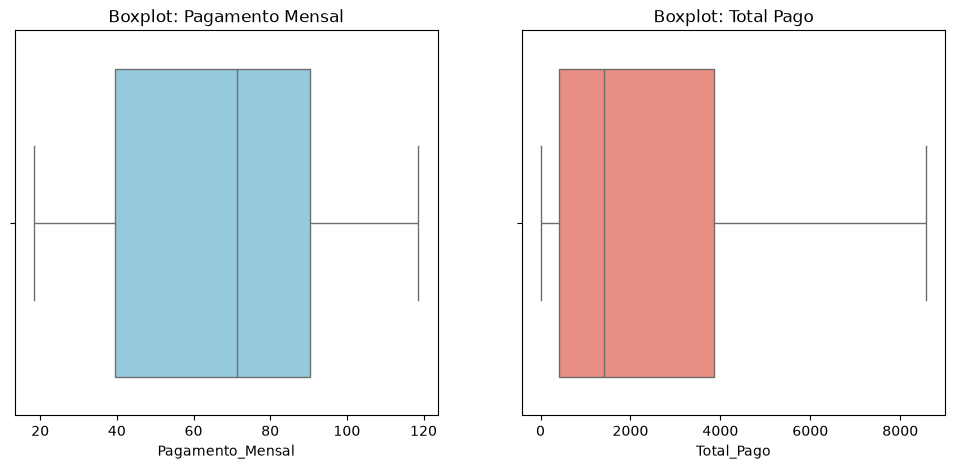

<Figure size 1500x1000 with 0 Axes>

In [14]:
# A) Describe
print("--- ITEM 2A: Describe ---")
print(df.describe())

# B) Outliers - Verificando boxplots para identificar
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Pagamento_Mensal'], color='skyblue')
plt.title('Boxplot: Pagamento Mensal')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Total_Pago'], color='salmon')
plt.title('Boxplot: Total Pago')
plt.savefig('outliers_check.png')
print("\nBoxplots salvos em 'outliers_check.png'")

# C) Gráficos Univariados (4 variáveis)
plt.figure(figsize=(15, 10))

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_19312\554227530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_19312\554227530.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Tipo_Contrato', palette='magma')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_19312\554227530.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Servico_Internet', palette='rocket')


Análise univariada salva em 'univariate_analysis.png'

--- ITEM 2D: Balanceamento ---

Variável: Idoso
Idoso
0    83.92
1    16.08
Name: proportion, dtype: float64

Variável: Churn
Churn
No     73.987976
Yes    26.012024
Name: proportion, dtype: float64


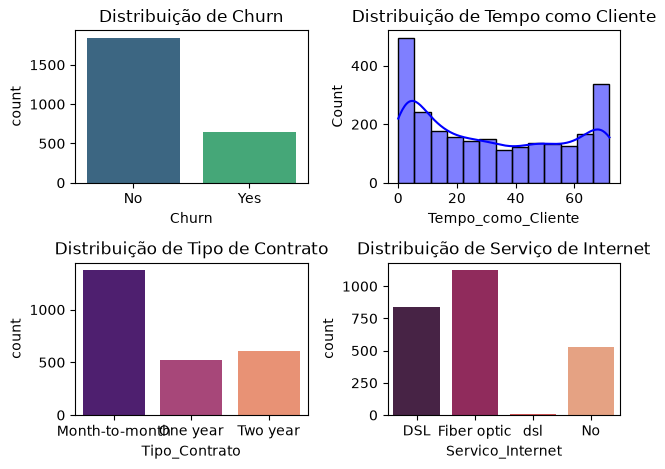

In [15]:
# 1. Churn
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribuição de Churn')

# 2. Tempo como Cliente
plt.subplot(2, 2, 2)
sns.histplot(df['Tempo_como_Cliente'], kde=True, color='blue')
plt.title('Distribuição de Tempo como Cliente')

# 3. Tipo de Contrato
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='Tipo_Contrato', palette='magma')
plt.title('Distribuição de Tipo de Contrato')

# 4. Servico de Internet
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='Servico_Internet', palette='rocket')
plt.title('Distribuição de Serviço de Internet')

plt.tight_layout()
plt.savefig('univariate_analysis.png')
print("Análise univariada salva em 'univariate_analysis.png'")

# D) Balanceamento Booleanas
print("\n--- ITEM 2D: Balanceamento ---")
for col in ['Idoso', 'Churn']:
    if col in df.columns:
        print(f"\nVariável: {col}")
        print(df[col].value_counts(normalize=True) * 100)

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

Análise bivariada salva em 'bivariate_analysis.png'


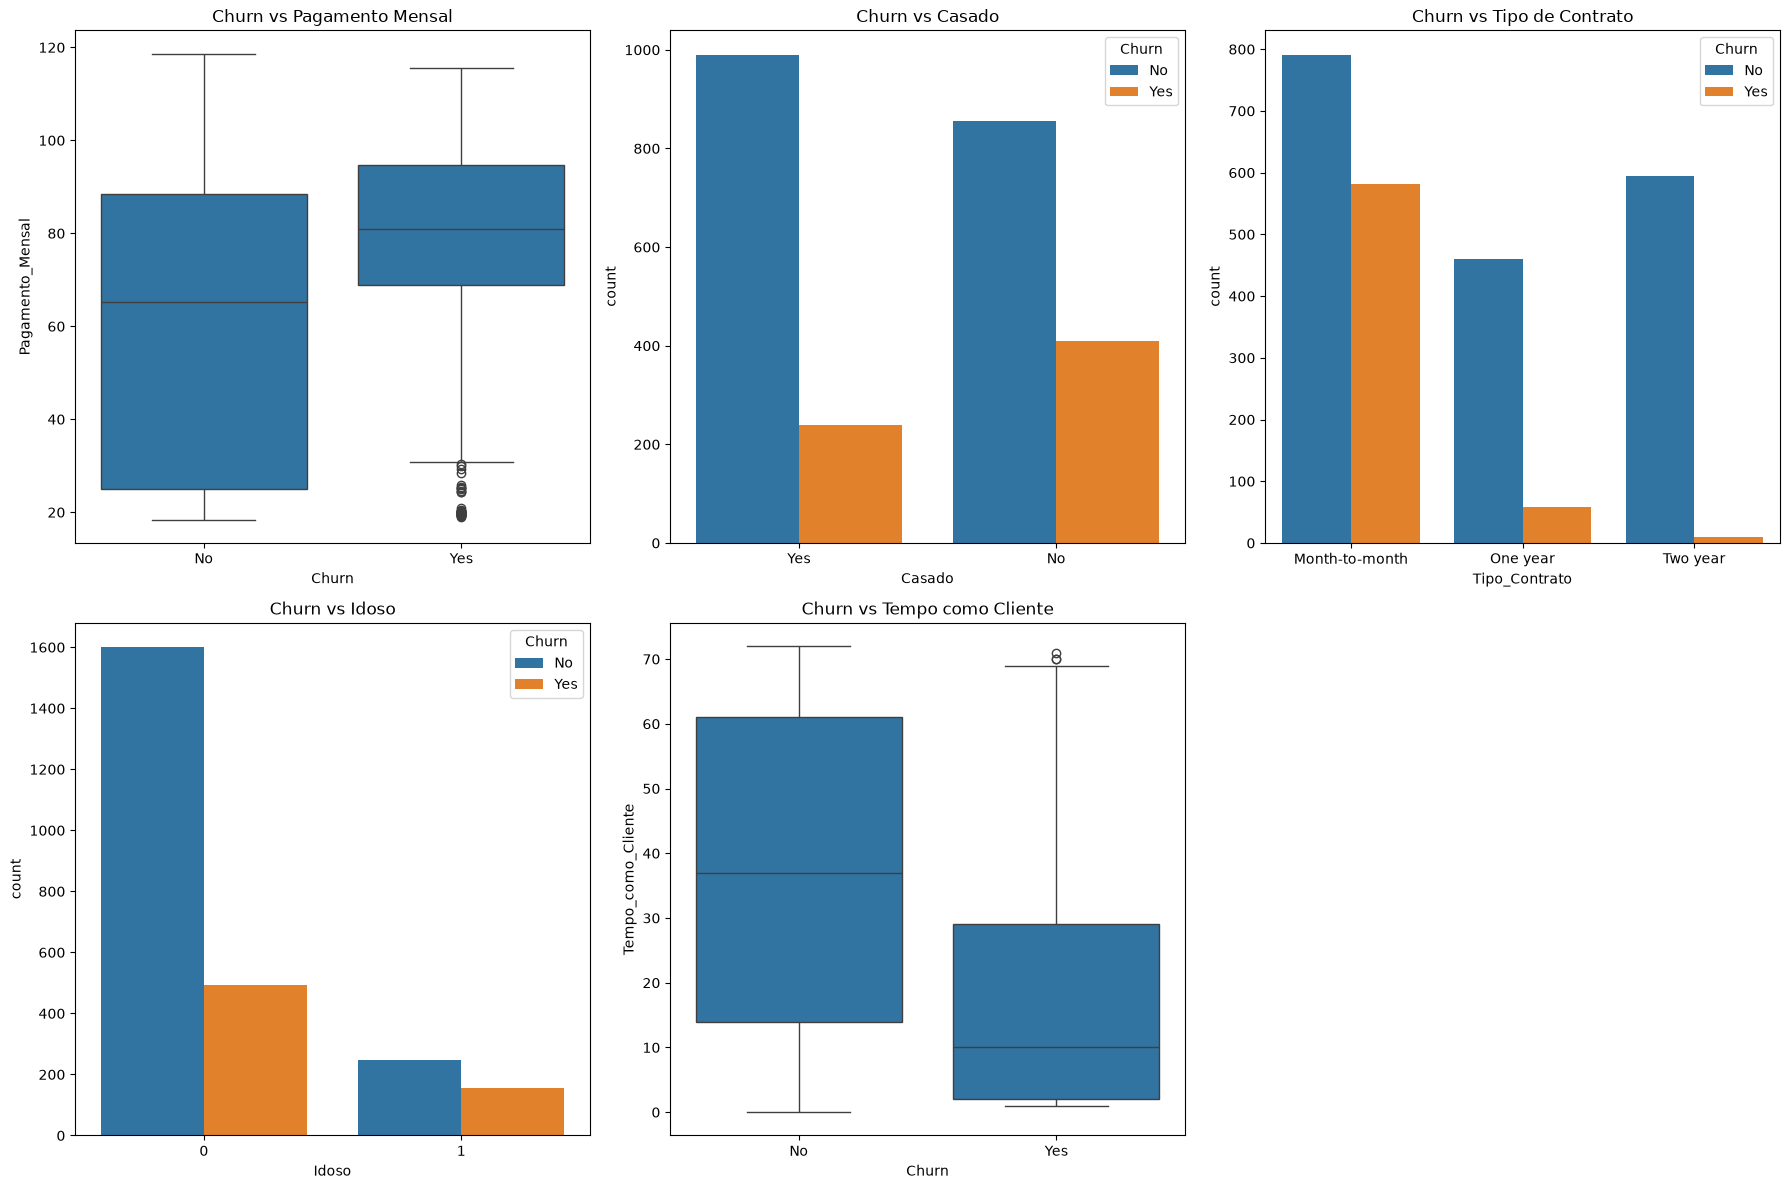

In [ ]:
# 4) Análise Bivariada
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
sns.boxplot(data=df, x='Churn', y='Pagamento_Mensal')
plt.title('Churn vs Pagamento Mensal')

plt.subplot(2, 3, 2)
sns.countplot(data=df, x='Casado', hue='Churn')
plt.title('Churn vs Casado')

plt.subplot(2, 3, 3)
sns.countplot(data=df, x='Tipo_Contrato', hue='Churn')
plt.title('Churn vs Tipo de Contrato')

plt.subplot(2, 3, 4)
sns.countplot(data=df, x='Idoso', hue='Churn')
plt.title('Churn vs Idoso')

plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='Churn', y='Tempo_como_Cliente')
plt.title('Churn vs Tempo como Cliente')

plt.tight_layout()
plt.savefig('bivariate_analysis.png')
print("Análise bivariada salva em 'bivariate_analysis.png'")